# STAT207 Mini-Project #2 - INSERT TITLE HERE


Mahlet Abebe

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf


## 1. Introduction

Primary Research Goal: Build a predictive model that will effectively predict Income of Chicago Neighborhoods for new datasets".
Secondary Research Goal: Ideally, we would like for our chosen model to also yield reliable interpretative insights about the nature of the relationship between the variables in the dataset.

The reason why someone may want to build a predictive model that predicts 'Income' of various Chicago neighborhoods is because identifying neighborhoods with lower predicted incomes can help focus economic development initiatives and investment opportunities. 
City Planners could use the model to allocate resources and develop programs in lower-income areas to promote economic growth and social equity.

# 2. Dataset Discussion

In [10]:
df = pd.read_csv('ChicagoData.csv')
df

,Community Area,name,population,income,requests,latinos,blacks,white,asian,other
0,1,Rogers Park,54991,39482,3204.888073,0.244,0.263,0.393,0.064,0.036
1,2,West Ridge,71942,47323,3906.341219,0.204,0.111,0.427,0.225,0.032
2,3,Uptown,56362,40324,2164.046698,0.142,0.200,0.516,0.114,0.028
3,4,Lincoln Square,39493,57749,3827.260527,0.191,0.038,0.631,0.111,0.029
4,5,North Center,31867,81524,5307.998870,0.136,0.023,0.773,0.045,0.022
...,...,...,...,...,...,...,...,...,...,...
72,73,Washington Heights,26493,42053,6641.754426,0.010,0.974,0.005,0.000,0.012
73,74,Mount Greenwood,19093,80505,4357.617975,0.072,0.052,0.860,0.007,0.010
74,75,Morgan Park,22544,56886,6264.194464,0.027,0.667,0.287,0.004,0.014
75,76,O'Hare,12756,49601,1552.994669,0.095,0.032,0.772,0.083,0.019


In [11]:
df.head()

,Community Area,name,population,income,requests,latinos,blacks,white,asian,other
0,1,Rogers Park,54991,39482,3204.888073,0.244,0.263,0.393,0.064,0.036
1,2,West Ridge,71942,47323,3906.341219,0.204,0.111,0.427,0.225,0.032
2,3,Uptown,56362,40324,2164.046698,0.142,0.200,0.516,0.114,0.028
3,4,Lincoln Square,39493,57749,3827.260527,0.191,0.038,0.631,0.111,0.029
4,5,North Center,31867,81524,5307.998870,0.136,0.023,0.773,0.045,0.022


There are 77 rows in our original dataset prior to any data cleaning. I was able to access this CSV file through Kaggle.com and I downloaded this dataset on March 28, 2025. Here is the link: https://www.kaggle.com/datasets/salikhussaini49/chicago-community-data?resource=download. 

## 3. Dataset Cleaning

In [12]:
df = pd.read_csv('ChicagoData.csv', keep_default_na=False, na_values=['', 'unknown'])
df

,Community Area,name,population,income,requests,latinos,blacks,white,asian,other
0,1,Rogers Park,54991,39482,3204.888073,0.244,0.263,0.393,0.064,0.036
1,2,West Ridge,71942,47323,3906.341219,0.204,0.111,0.427,0.225,0.032
2,3,Uptown,56362,40324,2164.046698,0.142,0.200,0.516,0.114,0.028
3,4,Lincoln Square,39493,57749,3827.260527,0.191,0.038,0.631,0.111,0.029
4,5,North Center,31867,81524,5307.998870,0.136,0.023,0.773,0.045,0.022
...,...,...,...,...,...,...,...,...,...,...
72,73,Washington Heights,26493,42053,6641.754426,0.010,0.974,0.005,0.000,0.012
73,74,Mount Greenwood,19093,80505,4357.617975,0.072,0.052,0.860,0.007,0.010
74,75,Morgan Park,22544,56886,6264.194464,0.027,0.667,0.287,0.004,0.014
75,76,O'Hare,12756,49601,1552.994669,0.095,0.032,0.772,0.083,0.019


In [13]:
df = df.dropna()
df

,Community Area,name,population,income,requests,latinos,blacks,white,asian,other
0,1,Rogers Park,54991,39482,3204.888073,0.244,0.263,0.393,0.064,0.036
1,2,West Ridge,71942,47323,3906.341219,0.204,0.111,0.427,0.225,0.032
2,3,Uptown,56362,40324,2164.046698,0.142,0.200,0.516,0.114,0.028
3,4,Lincoln Square,39493,57749,3827.260527,0.191,0.038,0.631,0.111,0.029
4,5,North Center,31867,81524,5307.998870,0.136,0.023,0.773,0.045,0.022
...,...,...,...,...,...,...,...,...,...,...
72,73,Washington Heights,26493,42053,6641.754426,0.010,0.974,0.005,0.000,0.012
73,74,Mount Greenwood,19093,80505,4357.617975,0.072,0.052,0.860,0.007,0.010
74,75,Morgan Park,22544,56886,6264.194464,0.027,0.667,0.287,0.004,0.014
75,76,O'Hare,12756,49601,1552.994669,0.095,0.032,0.772,0.083,0.019


In [14]:
dfdrop = df.drop(['Community Area','requests','other'], axis=1)
dfdrop


,name,population,income,latinos,blacks,white,asian
0,Rogers Park,54991,39482,0.244,0.263,0.393,0.064
1,West Ridge,71942,47323,0.204,0.111,0.427,0.225
2,Uptown,56362,40324,0.142,0.200,0.516,0.114
3,Lincoln Square,39493,57749,0.191,0.038,0.631,0.111
4,North Center,31867,81524,0.136,0.023,0.773,0.045
...,...,...,...,...,...,...,...
72,Washington Heights,26493,42053,0.010,0.974,0.005,0.000
73,Mount Greenwood,19093,80505,0.072,0.052,0.860,0.007
74,Morgan Park,22544,56886,0.027,0.667,0.287,0.004
75,O'Hare,12756,49601,0.095,0.032,0.772,0.083


In [15]:
dfdrop.isnull().sum()

name          0
population    0
income        0
latinos       0
blacks        0
white         0
asian         0
dtype: int64

In [16]:
df.shape[0] - dfdrop.shape[0]

0

The first step that I took towards cleaning my dataset was examining it for any implicit and explicit values. However, after converting '', and 'unknown' to NaN values in order to make sure that the data was ready for proper analysis. This step is important because missing values can lead to incorrect results if not handled appropriately. Once I dropped my missing values, I subracted our cleaned dataset from our original dataset, and realized that there were no missing values. However, there was a column that I felt was irrelevent to our research goals ('Community Area') because the column just contained numbers (ex: Community 1, Community 2, and so forth) instead of neighborhood names, which wouldn't provide meaningful insights for predicting income. Therefore, I removed this column to simplify the dataset and keep only relevant variables for the predictive model. I also removed 'requests' and 'other' from our dataset as I felt that it would be irrelevant in regards to my research goal. 



## 4. Preliminary Analysis

In [17]:
dfnumerical = dfdrop[['population', 'latinos', 'asian', 'blacks', 'white']]
dfnumerical


,population,latinos,asian,blacks,white
0,54991,0.244,0.064,0.263,0.393
1,71942,0.204,0.225,0.111,0.427
2,56362,0.142,0.114,0.200,0.516
3,39493,0.191,0.111,0.038,0.631
4,31867,0.136,0.045,0.023,0.773
...,...,...,...,...,...
72,26493,0.010,0.000,0.974,0.005
73,19093,0.072,0.007,0.052,0.860
74,22544,0.027,0.004,0.667,0.287
75,12756,0.095,0.083,0.032,0.772


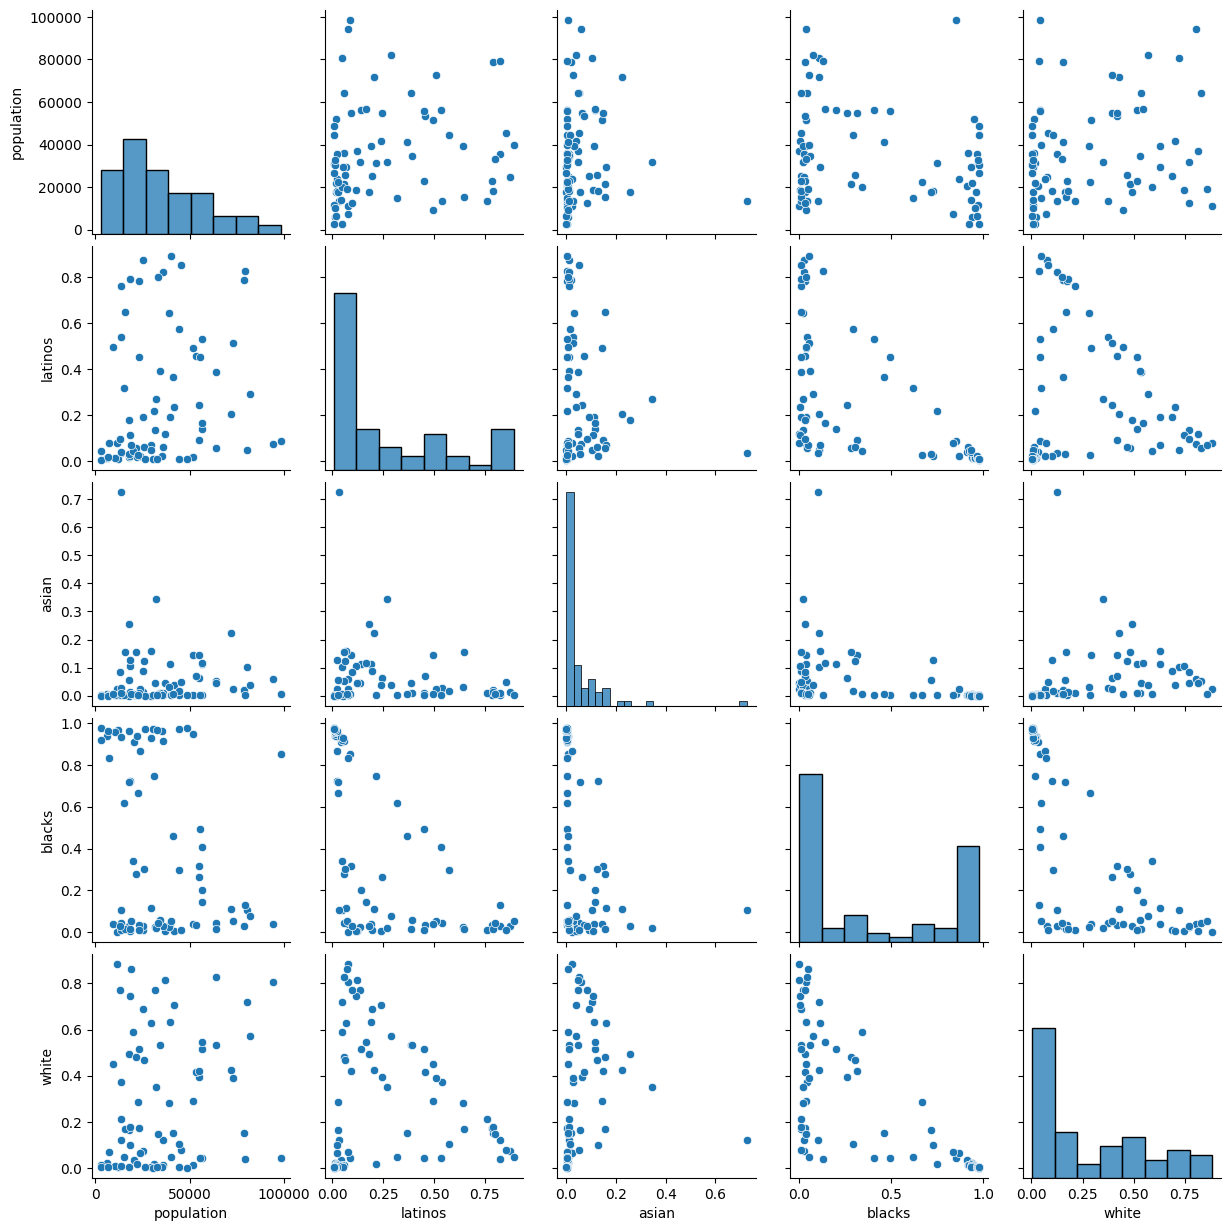

In [18]:
sns.pairplot(dfnumerical)

In [19]:
linreg = smf.ols(formula='income ~ population + latinos + asian + blacks + white', data=dfdrop).fit()
linreg

In [20]:
linreg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 income   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.696
Method:                 Least Squares   F-statistic:                     35.81
Date:                Fri, 04 Apr 2025   Prob (F-statistic):           4.01e-18
Time:                        19:46:11   Log-Likelihood:                -812.89
No. Observations:                  77   AIC:                             1638.
Df Residuals:                      71   BIC:                             1652.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -5.943e+04   1.64e+05     -0.362      0.718   -3.87e+05    2.68e+05
population    -0.0106      0.052     -0.203      0.840      -0.115       0.094
latinos     9.392e+04   1.64e+05      0.571      0.570   -2.34e+05    4.22e+05
asian        7.91e+04    1.7e+05      0.466      0.643   -2.59e+05    4.18e+05
blacks      9.165e+04   1.66e+05      0.551      0.583    -2.4e+05    4.23e+05
white       1.466e+05   1.68e+05      0.873      0.386   -1.88e+05    4.82e+05
==============================================================================
Omnibus:                        3.917   Durbin-Watson:                   1.536
Prob(Omnibus):                  0.141   Jarque-Bera (JB):                3.118
Skew:                           0.448   Prob(JB):                        0.210
Kurtosis:                       3.410   Cond. No.                     1.40e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.4e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Text(0, 0.5, 'Residuals')

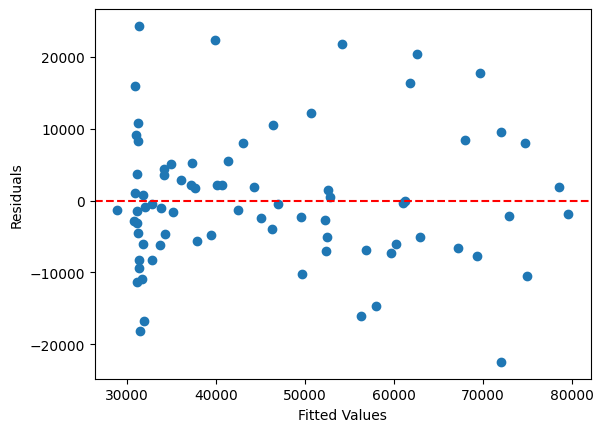

In [21]:
plt.scatter(linreg.fittedvalues, linreg.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')


By defining patterns and minimizing inconsistencies, conducting a log transformation on variables like income or population could potentially enhance the model.  Additionally, addressing factors relating to race may help prevent redundancy and increase accuracy. To sum it up, these changes might make the predictions more reliable and better reflect real-world trends.

In [22]:
dfdrop['log_population'] = np.log(dfdrop['population'])
dfdrop['log_latinos'] = np.log(dfdrop['latinos'])


logtransformation = smf.ols(formula='income ~ log_population + log_latinos + asian + blacks + white', data=dfdrop).fit()
logtransformation.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 income   R-squared:                       0.718
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     36.16
Date:                Fri, 04 Apr 2025   Prob (F-statistic):           3.14e-18
Time:                        19:46:11   Log-Likelihood:                -812.62
No. Observations:                  77   AIC:                             1637.
Df Residuals:                      71   BIC:                             1651.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept        2.54e+04   1.69e+04      1.500      0.138   -8369.622    5.92e+04
log_population   929.7568   1589.118      0.585      0.560   -2238.855    4098.368
log_latinos    -1854.9346   2223.986     -0.834      0.407   -6289.437    2579.567
asian           -2.39e+04   1.44e+04     -1.661      0.101   -5.26e+04    4791.167
blacks         -1.144e+04   1.15e+04     -0.997      0.322   -3.43e+04    1.14e+04
white           4.454e+04   9306.914      4.785      0.000     2.6e+04    6.31e+04
==============================================================================
Omnibus:                        5.896   Durbin-Watson:                   1.526
Prob(Omnibus):                  0.052   Jarque-Bera (JB):                5.107
Skew:                           0.572   Prob(JB):                       0.0778
Kurtosis:                       3.531   Cond. No.                         181.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0, 0.5, 'Residuals')

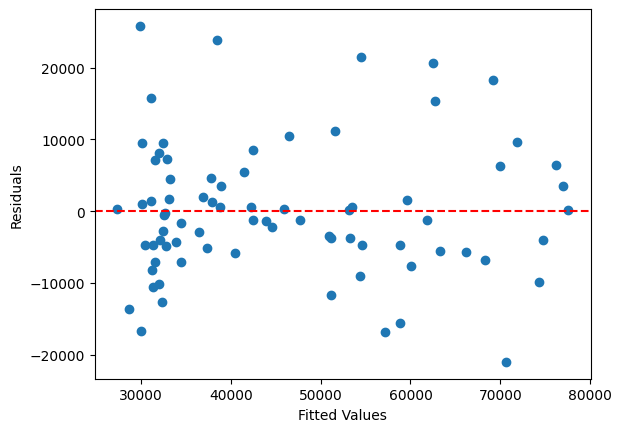

In [23]:
plt.scatter(logtransformation.fittedvalues, logtransformation.resid)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

By defining patterns and minimizing inconsistencies, conducting a log transformation on variables like income or population could potentially enhance the model.  Additionally, addressing factors relating to race may help prevent redundancy and increase accuracy. To sum it up, these changes might make the predictions more reliable and better reflect real-world trends. After doing a transformation, the residuals in the second residual plot are slightly more randomly distributed, lack a clear pattern, and have a slightly more even distribution of positive and negative values. Therefore, the second residual plot more closely aligns with the linearity assumption rule.  The first plot, on the other hand, indicates potential non-linearity due to its obvious clustering and fluctuation, especially at lower fitted values. Although  There is still some non-constant variation in the second plot, it is not as bad as the first residual plot.


In [24]:
dfsort = dfdrop.sort_values(by="income", ascending=True)
top15 = dfsort.tail(15)
top15


,name,population,income,latinos,blacks,white,asian,log_population,log_latinos
55,Garfield Ridge,34513,61206,0.392,0.059,0.532,0.010,10.449091,-0.936493
16,Dunning,41932,61584,0.238,0.007,0.704,0.038,10.643805,-1.435485
69,Ashburn,41081,62238,0.368,0.462,0.152,0.007,10.623301,-0.999672
27,Near West Side,54881,62770,0.092,0.315,0.420,0.146,10.912922,-2.385967
9,Norwood Park,37023,64477,0.120,0.004,0.815,0.046,10.519295,-2.120264
5,Lake View,94368,70746,0.076,0.039,0.804,0.060,11.454957,-2.577022
32,Near South Side,21390,75995,0.056,0.281,0.481,0.155,9.970679,-2.882404
7,Near North Side,80484,76290,0.049,0.108,0.721,0.101,11.295814,-3.015935
8,Edison Park,11187,77678,0.078,0.003,0.884,0.024,9.322508,-2.551046
31,Loop,29283,78124,0.069,0.115,0.627,0.159,10.284762,-2.673649


In [25]:
bottom15 = dfsort.head(15)
bottom15

,name,population,income,latinos,blacks,white,asian,log_population,log_latinos
53,Riverdale,6482,13380,0.020,0.964,0.005,0.000,8.776784,-3.912023
36,Fuller Park,2876,15086,0.046,0.922,0.016,0.002,7.964156,-3.079114
67,Englewood,30654,19743,0.011,0.974,0.003,0.001,10.330518,-4.509860
35,Oakland,5918,20800,0.015,0.941,0.021,0.006,8.685754,-4.199705
39,Washington Park,11717,21899,0.009,0.970,0.007,0.001,9.368796,-4.710531
25,West Garfield Park,18001,23033,0.019,0.962,0.007,0.000,9.798183,-3.963316
26,East Garfield Park,20567,24488,0.041,0.909,0.034,0.004,9.931443,-3.194183
28,North Lawndale,35912,25797,0.060,0.914,0.014,0.002,10.488827,-2.813411
66,West Englewood,35505,26654,0.022,0.963,0.004,0.001,10.477429,-3.816713
41,Woodlawn,23740,27413,0.021,0.868,0.068,0.023,10.074917,-3.863233


In [26]:
combineneighborhood = pd.concat([top15, bottom15])
combineneighborhood

,name,population,income,latinos,blacks,white,asian,log_population,log_latinos
55,Garfield Ridge,34513,61206,0.392,0.059,0.532,0.010,10.449091,-0.936493
16,Dunning,41932,61584,0.238,0.007,0.704,0.038,10.643805,-1.435485
69,Ashburn,41081,62238,0.368,0.462,0.152,0.007,10.623301,-0.999672
27,Near West Side,54881,62770,0.092,0.315,0.420,0.146,10.912922,-2.385967
9,Norwood Park,37023,64477,0.120,0.004,0.815,0.046,10.519295,-2.120264
5,Lake View,94368,70746,0.076,0.039,0.804,0.060,11.454957,-2.577022
32,Near South Side,21390,75995,0.056,0.281,0.481,0.155,9.970679,-2.882404
7,Near North Side,80484,76290,0.049,0.108,0.721,0.101,11.295814,-3.015935
8,Edison Park,11187,77678,0.078,0.003,0.884,0.024,9.322508,-2.551046
31,Loop,29283,78124,0.069,0.115,0.627,0.159,10.284762,-2.673649


By reducing the sample size from 77 rows to 30 rows (top and bottom 15 neighborhoods in terms of average income), we can avoid noise and trends are easier to spot, improving visualization quality. By choosing a representative selection of neighborhoods, it makes the analysis more accurate and manageable while enabling more targeted findings. A smaller dataset also helps address data sparsity and makes communication of results clearer. This method prevents overfitting and guarantees statistical significance as long as the neighborhoods chosen are meaningful.  In general, lowering the sample size maintains accuracy while improving understanding.

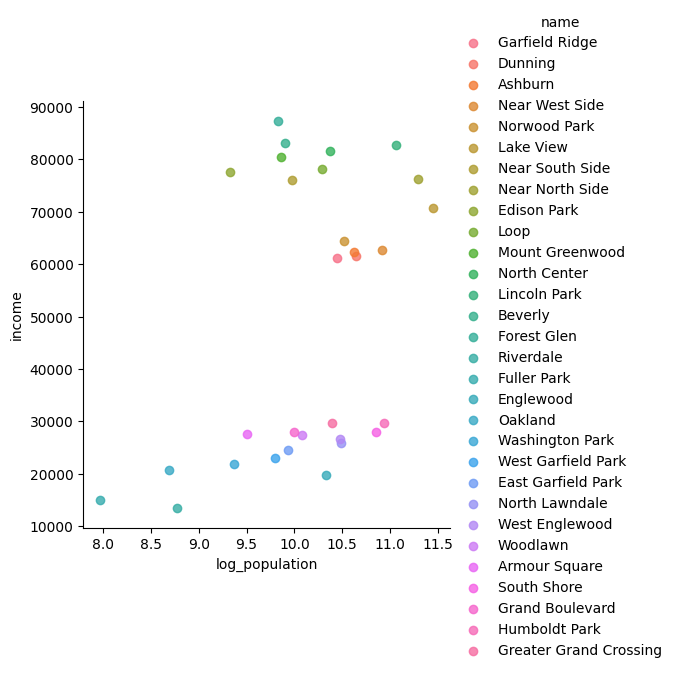

In [28]:
sns.lmplot(data=combineneighborhood, x='log_population', y='income', hue='name')



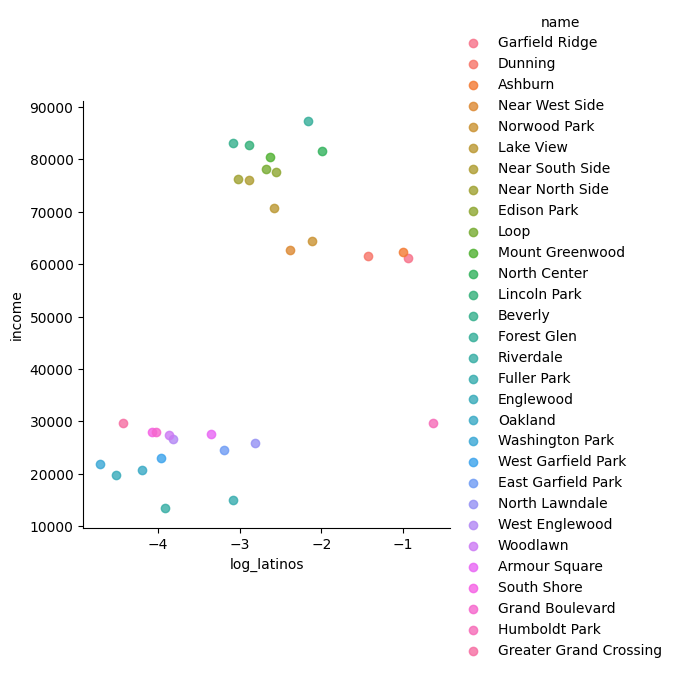

In [29]:
sns.lmplot(data=combineneighborhood, x='log_latinos', y='income', hue='name')



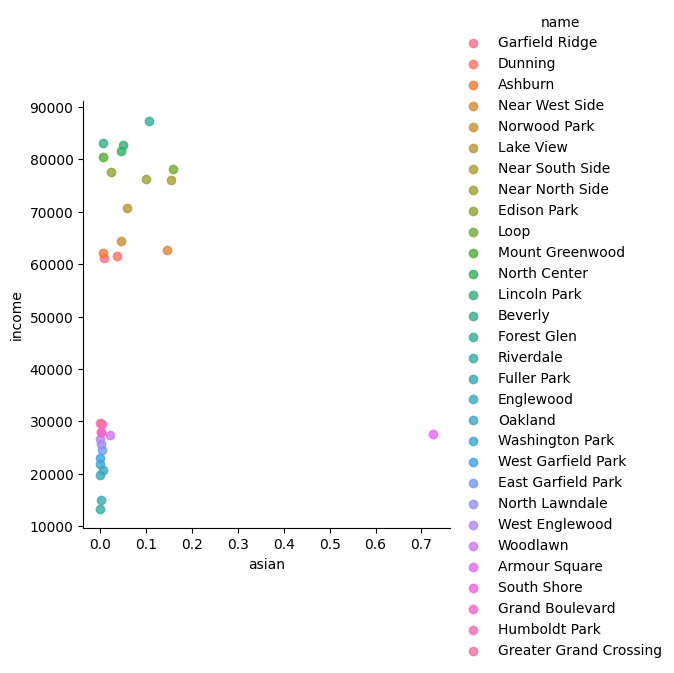

In [30]:
sns.lmplot(data=combineneighborhood, x='asian', y='income', hue='name')



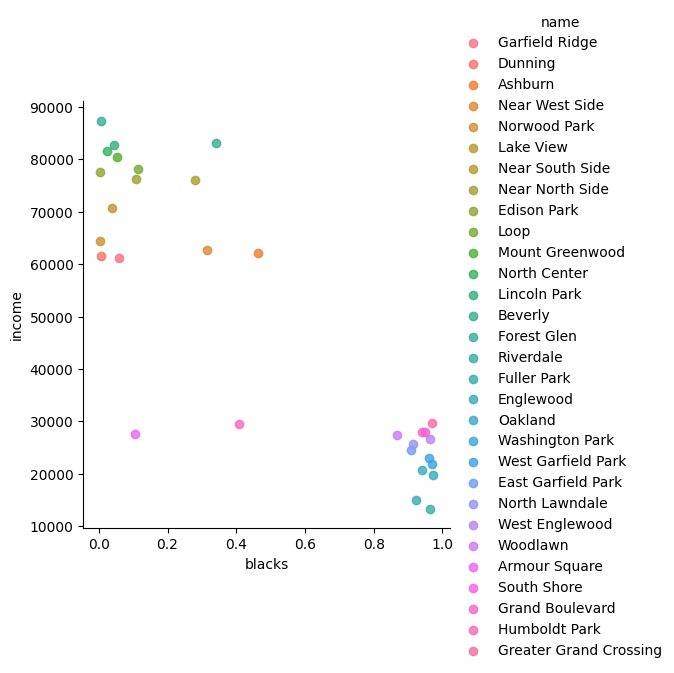

In [31]:
sns.lmplot(x='blacks', y='income', hue='name', ci=False, data=combineneighborhood) 
plt.show()



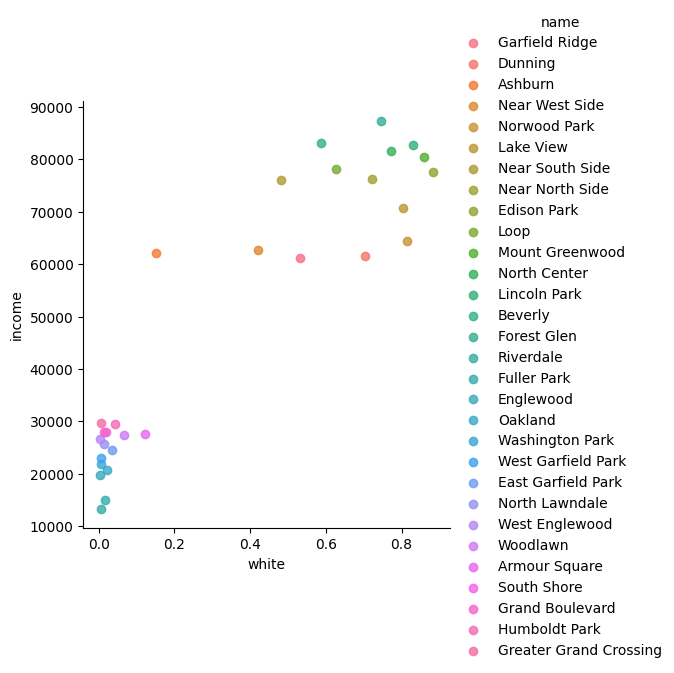

In [32]:
sns.lmplot(data=combineneighborhood, x='white', y='income', hue='name')



## 5. Predictive Models

In [34]:
df_train, df_test = train_test_split(combineneighborhood, test_size = 0.2, random_state = 437)

In [35]:
df_train.head()

,name,population,income,latinos,blacks,white,asian,log_population,log_latinos
11,Forest Glen,18508,87394,0.115,0.007,0.746,0.107,9.825958,-2.162823
22,Humboldt Park,56323,29605,0.533,0.409,0.044,0.004,10.938858,-0.629234
27,Near West Side,54881,62770,0.092,0.315,0.420,0.146,10.912922,-2.385967
42,South Shore,52010,27903,0.017,0.949,0.014,0.002,10.859191,-4.074542
7,Near North Side,80484,76290,0.049,0.108,0.721,0.101,11.295814,-3.015935


In [36]:
df_test.head()

,name,population,income,latinos,blacks,white,asian,log_population,log_latinos
9,Norwood Park,37023,64477,0.120,0.004,0.815,0.046,10.519295,-2.120264
73,Mount Greenwood,19093,80505,0.072,0.052,0.860,0.007,9.857077,-2.631089
16,Dunning,41932,61584,0.238,0.007,0.704,0.038,10.643805,-1.435485
26,East Garfield Park,20567,24488,0.041,0.909,0.034,0.004,9.931443,-3.194183
41,Woodlawn,23740,27413,0.021,0.868,0.068,0.023,10.074917,-3.863233


In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
zscaletrain = scaler.fit_transform(df_train[['log_population', 'log_latinos', 'blacks', 'white', 'asian']])
zscaletrain = pd.DataFrame(zscaletrain, columns=['log_population', 'log_latinos', 'blacks', 'white', 'asian'])
pd.DataFrame(zscaletrain)




,log_population,log_latinos,blacks,white,asian
0,-0.336161,0.923810,-1.290854,1.303755,0.271100
1,0.986302,2.415220,-0.298728,-0.769064,-0.428440
2,0.955483,0.706803,-0.530718,0.341164,0.535975
3,0.891634,-0.935330,1.033979,-0.857646,-0.442023
4,1.410474,0.094161,-1.041588,1.229937,0.230350
5,-1.582898,-0.777281,1.070998,-0.884221,-0.455607
6,0.209038,0.427033,-1.024313,0.952380,0.624266
7,1.140296,0.224020,-1.202007,1.548832,-0.109232
8,-0.242014,0.032720,-0.466550,0.837223,-0.414857
9,-2.548548,0.032720,0.967343,-0.851741,-0.442023


In [38]:
zscaletest = scaler.transform(df_test[['log_population', 'log_latinos', 'blacks', 'white', 'asian']])

pd.DataFrame(zscaletest)

,0,1,2,3,4
0,0.487733,0.965199,-1.298258,1.507494,-0.143191
1,-0.299182,0.468423,-1.179795,1.640367,-0.408065
2,0.635689,1.631144,-1.290854,1.179741,-0.197524
3,-0.210813,-0.079184,0.935260,-0.798592,-0.428440
4,-0.040323,-0.729833,0.834073,-0.698199,-0.299399
5,0.404310,2.116411,-1.162519,0.671870,-0.387690


# 5.1. Non-Regularized Linear Regression Full Model

In [39]:
linmodel = smf.ols(formula="income ~ log_population + log_latinos + blacks + white + asian", data=df_train).fit()
linmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 income   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     35.09
Date:                Fri, 04 Apr 2025   Prob (F-statistic):           1.13e-08
Time:                        19:46:14   Log-Likelihood:                -250.37
No. Observations:                  24   AIC:                             512.7
Df Residuals:                      18   BIC:                             519.8
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       6259.1328   4.11e+04      0.152      0.881   -8.01e+04    9.26e+04
log_population  2790.9700   2611.400      1.069      0.299   -2695.378    8277.318
log_latinos     4377.3455   5877.032      0.745      0.466   -7969.840    1.67e+04
blacks          7625.7311   4.71e+04      0.162      0.873   -9.13e+04    1.07e+05
white           7.424e+04   4.08e+04      1.821      0.085   -1.14e+04     1.6e+05
asian           4946.0422   4.53e+04      0.109      0.914   -9.02e+04       1e+05
==============================================================================
Omnibus:                        1.041   Durbin-Watson:                   2.704
Prob(Omnibus):                  0.594   Jarque-Bera (JB):                0.680
Skew:                           0.405   Prob(JB):                        0.712
Kurtosis:                       2.845   Cond. No.                         456.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [40]:
from sklearn.metrics import r2_score
testpredict = linmodel.predict(df_test)
testactual = df_test['income']
r2_score(testactual, testpredict)


0.5580703753749181

# 5.2. Non-Regularized Linear Regression Full Model with Interaction Terms

In [41]:
interactionlin = smf.ols(formula='income ~ log_population*name + log_latinos*name + blacks*name + white*name + asian*name', data=df_train).fit()
interactionlin.summary()


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/statsmodels/base/model.py:1527: RuntimeWarning: invalid value encountered in multiply
  cov_p = self.normalized_cov_params * scale


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 income   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 04 Apr 2025   Prob (F-statistic):                nan
Time:                        19:46:14   Log-Likelihood:                 504.18
No. Observations:                  24   AIC:                            -960.4
Df Residuals:                       0   BIC:                            -932.1
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
=================================================================================================================
                                                    coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------
Intercept                                       108.3569        inf          0        nan         nan         nan
name[T.Ashburn]                                 194.6936        inf          0        nan         nan         nan
name[T.Beverly]                                 465.5521        inf          0        nan         nan         nan
name[T.Edison Park]                             478.1717        inf          0        nan         nan         nan
name[T.Englewood]                               -69.0920        inf         -0        nan         nan         nan
name[T.Forest Glen]                             512.1478        inf          0        nan         nan         nan
name[T.Fuller Park]                            -108.1107        inf         -0        nan         nan         nan
name[T.Grand Boulevard]                          -5.5970        inf         -0        nan         nan         nan
name[T.Greater Grand Crossing]                    3.9932        inf          0        nan         nan         nan
name[T.Humboldt Park]                          -101.2542        inf         -0        nan         nan         nan
name[T.Lake View]                               218.1402        inf          0        nan         nan         nan
name[T.Lincoln Park]                            337.2515        inf          0        nan         nan         nan
name[T.Loop]                                    378.9463        inf          0        nan         nan         nan
name[T.Near North Side]                         275.5173        inf          0        nan         nan         nan
name[T.Near South Side]                         397.8386        inf          0        nan         nan         nan
name[T.Near West Side]                          199.8051        inf          0        nan         nan         nan
name[T.North Center]                            388.8755        inf          0        nan         nan         nan
name[T.North Lawndale]                          -67.9339        inf         -0        nan         nan         nan
name[T.Oakland]                                 -23.1049        inf         -0        nan         nan         nan
name[T.Riverdale]                              -113.7935        inf         -0        nan         nan         nan
name[T.South Shore]                             -29.8247        inf         -0        nan         nan         nan
name[T.Washington Park]                         -21.4115        inf         -0        nan         nan         nan
name[T.West Englewood]                          -35.4345        inf         -0        nan         nan         nan
name[T.West Garfield Park]                      -44.0309        inf         -0        nan         nan         nan
log_p

Since several of the predictor variables in the model above are strongly correlated, it is challenging to determine the specific impact of each variable alone due to severe multicollinearity. As a result, the test R-squared cannot be calculated due to unreliable coefficients and exaggerated standard errors. Furthermore, the absence of slopes for the interaction terms implies that the model isn't accurately representing the combined effects of predictors, which is crucial for comprehending the relationship between variables. Therefore,this model is not a good fit for our primary research question, and I will be removing 'name' from our models going forward. 







# Forward Selection Algorithim

In [42]:
currentmodel = smf.ols('income~1', data=df_train).fit()
y_pred_test = currentmodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

-0.07151018385412633

In [43]:
testmodel = smf.ols('income~log_population', data=df_train).fit()
y_pred_test = testmodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.0443058625206596

In [44]:
testmodel = smf.ols('income~log_latinos', data=df_train).fit()
y_pred_test = testmodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.3278984198335728

In [45]:
testmodel = smf.ols('income~blacks', data=df_train).fit()
y_pred_test = testmodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.7225392359341403

In [46]:
testmodel = smf.ols('income~white', data=df_train).fit()
y_pred_test = testmodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.6691805262714804

In [47]:
testmodel = smf.ols('income~asian', data=df_train).fit()
y_pred_test = testmodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

-0.08847154949109104

In [48]:
current_model = smf.ols('income~blacks', data=df_train).fit()
y_pred_test = current_model.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.7225392359341403

In [49]:
test_model = smf.ols('income~blacks+log_population', data=df_train).fit()
y_pred_test = test_model.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.7026918760600167

In [50]:
test_model = smf.ols('income~blacks+log_latinos', data=df_train).fit()
y_pred_test = test_model.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.753252095496645

In [51]:
test_model = smf.ols('income~blacks+white', data=df_train).fit()
y_pred_test = test_model.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.6618280541973217

In [52]:
test_model = smf.ols('income~blacks+asian', data=df_train).fit()
y_pred_test = test_model.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.3858045793011705

In [53]:
current_model = smf.ols('income~blacks+log_latinos', data=df_train).fit()
y_pred_test = current_model.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.753252095496645

In [54]:
temodel = smf.ols('income~blacks+log_latinos+log_population', data=df_train).fit()
y_pred_test = temodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.7494682837179223

In [55]:
temodel = smf.ols('income~blacks+log_latinos+white', data=df_train).fit()
y_pred_test = temodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.5373765722354349

In [56]:
temodel = smf.ols('income~blacks+log_latinos+asian', data=df_train).fit()
y_pred_test = temodel.predict(df_test)
r2_score(df_test['income'], y_pred_test)

0.5139776023635438

# Final Model for Forward Algorithim

In [57]:
finalmodel = smf.ols('income~blacks+log_latinos', data=df_train).fit()

In [58]:
finalmodel.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 income   R-squared:                       0.766
Model:                            OLS   Adj. R-squared:                  0.744
Method:                 Least Squares   F-statistic:                     34.45
Date:                Fri, 04 Apr 2025   Prob (F-statistic):           2.34e-07
Time:                        19:46:15   Log-Likelihood:                -261.42
No. Observations:                  24   AIC:                             528.8
Df Residuals:                      21   BIC:                             532.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    7.619e+04   9391.336      8.113      0.000    5.67e+04    9.57e+04
blacks      -5.993e+04   9252.334     -6.477      0.000   -7.92e+04   -4.07e+04
log_latinos -1091.7495   3645.848     -0.299      0.768   -8673.704    6490.205
==============================================================================
Omnibus:                       20.874   Durbin-Watson:                   1.857
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               31.389
Skew:                          -1.705   Prob(JB):                     1.53e-07
Kurtosis:                       7.445   Cond. No.                         13.5
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [59]:
df_train[['blacks', 'log_latinos', 'white','asian' ,'log_population']].corr()


,blacks,log_latinos,white,asian,log_population
blacks,1.000000,-0.653162,-0.896546,-0.437516,-0.356512
log_latinos,-0.653162,1.000000,0.453338,0.073250,0.341624
white,-0.896546,0.453338,1.000000,0.116068,0.331881
asian,-0.437516,0.073250,0.116068,1.000000,-0.036749
log_population,-0.356512,0.341624,0.331881,-0.036749,1.000000


In [60]:
testpredictions = finalmodel.predict(df_test)
actualtests = df_test['income']
r2_score(actualtests, testpredictions) 

0.753252095496645

## 6. Best Model Discussion

After making various models for my Chicago dataset, I can conclude that my Forwards Selection Model was my best one as it had the highest test r^2 (0.753), and my equation for this said model is Y = ^income=76190−59930⋅blacks−1091.75⋅log(latinos). Since my test r^2 is approx. 0.753, the model explains 75.3% of the variation in 'income'. This means the model is a overall decent fit for our test dataset, and only 24.7% of the variation remains unexplained by the variables in the model. In addition to this, there may have been some overfitting in that this model didn't include 'white' and 'asian' as well as multicollinearity as the correlation between 'blacks' and 'white' was -0.896546, which is way above 0.7(our threshold for multicollinearity). Something that I did for my models was use my original training dataset instead of the scaled training dataset and this is because my variables are on similar scales. 
if the variables in a linear regression model are on similar scales, you can use the slope magnitudes to assess the relative significance of the explanatory factors. Keeping everything else equal, income decreases by about $59,930 for every unit increase of blacks while there is a $1,091.75 decrease in income for every unit increase in log_latinos.  Therefore, blacks has a much larger effect on predicted income than log_latinos, assuming units are somewhat comparable.



## 7. Conclusion

Out of all the available models for this dataset, we can't be sure that the model that is selected will produce the highest test R-squared. There is no guarantee that this model is the best without evaluating different combinations of predictors, transformations, and modeling strategies.  A deeper analysis  would use regularization strategies (Lasso, Ridge), cross-validation, feature selection strategies. and predictor transformations  to strengthen the model. Some shortcomings that I had in this analysis include encountering several cases of multicollinearity, so I ended up removing some of my variables ('name', 'other') from my dataset. I could, for instance, use quick encoding to encode any categorical variables and incorporate them into the model. Addtionally, I could have looked into more interactions between our variables as I was specifically focused on the interaction between race, income, and neighborhood. Log-transforming variables that may have a skewed distribution is another easy step that could improve model performance.  Finally, i could try experimenting with cross-validation to evaluate the model's performance more thoroughly and make sure it performs well when applied to fresh data.